# NYC Construction Permit Approval Duration
## Tree-Based Models

This notebook applies a Random Forest regression model to assess whether 
non-linear relationships between predictors can improve on the linear 
baseline. Feature importance is examined to identify the strongest predictors 
of permit approval duration.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('permit_model_data.csv')

X = df.drop(columns=['approval_duration'])
y = df['approval_duration']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Random Forest Model

A Random Forest ensemble is fit using cross-validated hyperparameter defaults. 
Performance is evaluated on the held-out test set and compared against the 
linear baseline.

In [2]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest — RMSE: {rmse_rf:.2f} | R²: {r2_rf:.4f}")

Random Forest — RMSE: 52.70 | R²: -0.0234


#### Feature Importance

Despite lower predictive performance, we examine feature importance scores to 
identify which predictors the model weighted most heavily.

In [3]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top10 = importances.sort_values(ascending=False).head(10)
print(top10)

residential_YES          0.129347
bldg_type_2              0.095274
borough_QUEENS           0.084478
borough_MANHATTAN        0.068961
borough_STATEN ISLAND    0.064885
job_type_NB              0.064795
borough_BROOKLYN         0.058367
job_type_A2              0.051660
permit_type_NB           0.043809
permit_type_FO           0.032122
dtype: float64


#### Feature Importance Plot

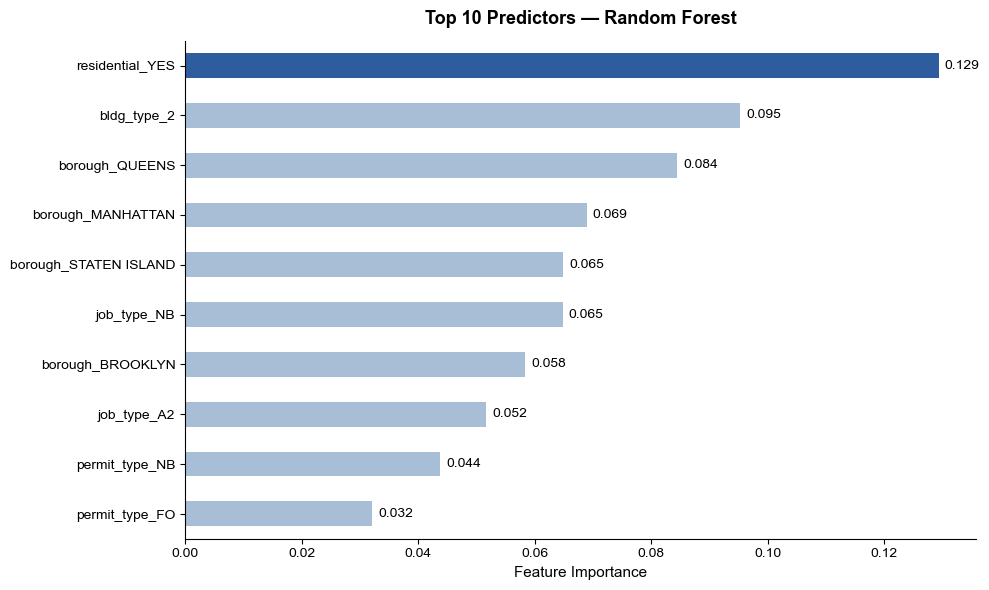

In [5]:
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#2E5D9F' if i == 0 else '#A8BDD6' for i in range(len(top10))]
top10.sort_values().plot(kind='barh', ax=ax, color=colors[::-1], width=0.5)

ax.set_xlabel('Feature Importance', fontsize=11)
ax.set_title('Top 10 Predictors — Random Forest', fontsize=13, fontweight='bold', pad=12)

for i, v in enumerate(top10.sort_values()):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

#### Results and Interpretation

The Random Forest model yields an RMSE of 52.70 and R² of -0.023, performing 
slightly worse than the linear baseline. The negative R² indicates the model 
is overfitting to the training data and failing to generalize — likely a 
consequence of the limited signal in the available features rather than model 
structure.

Despite this, feature importance scores reveal meaningful patterns. Residential 
classification is the strongest predictor, followed by building type and borough. 
This suggests that where and what

#### Summary

The Random Forest model does not outperform linear regression on this dataset, 
confirming that the available categorical features lack sufficient predictive 
power regardless of model complexity. However, feature importance analysis 
provides interpretable insight into which project characteristics are most 
associated with approval duration. These findings are synthesized alongside 
all models in Notebook 6.